## MODULO6 -- TAE EN INTELIGENCIA ARTIFICIAL "IA"
# 🐲 🤖 👽 👏

 ## 🧑‍🏫 *Professor* 🧑‍🏫 : Dr Francisco Rodriguez

 ## 👨‍🎓 *Student*: 👨‍🎓 : Cesar Eduardo Inda Ceniceros

# TAE-IA · Module 6 · L01 — Your First AI Image: The diffusers Library

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L01 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Load a Stable Diffusion pipeline using the `diffusers` library with Drive-cached weights
- [ ] Generate text-to-image outputs with a fixed seed for reproducibility
- [ ] Explain the role of `num_inference_steps` and `guidance_scale` with documented evidence
- [ ] Identify at least two ethical risks of text-to-image generation

## Before you start
- Google account with Google Drive available
- Colab configured with T4 GPU runtime (`Runtime > Change runtime type > T4 GPU`)
- This is the first lesson — no prerequisites beyond the course introduction

---

## Cell 0 — Setup (always run this first)

> This cell mounts your Google Drive, checks the GPU, installs dependencies, and fixes the random seed.  
> **First run:** downloads ~4 GB of model weights to Drive (~5 min).  
> **Subsequent runs:** loads from Drive in ~30 seconds.

In [10]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

# --- 1. Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# --- 2. Point Hugging Face and PyTorch to Drive ---
os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

# --- 3. GPU check ---
import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected.')
    print('Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required to continue.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9
print(f'GPU: {gpu_name}  |  Total VRAM: {vram_gb:.1f} GB  |  Free VRAM: {vram_free:.1f} GB')

# --- 4. Fixed seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')

# --- 5. Versions ---
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}  |  CUDA {torch.version.cuda}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  Total VRAM: 15.6 GB  |  Free VRAM: 12.9 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128  |  CUDA 12.8


In [2]:
# ================================================================
# Install dependencies for L01
# ================================================================
!pip install diffusers transformers accelerate -q

import diffusers, transformers
print(f'diffusers {diffusers.__version__}  |  transformers {transformers.__version__}')

diffusers 0.40.0  |  transformers 5.15.1


## Cell 0b — HuggingFace Login (needed every new Colab session)

> Colab wipes your login state every time you get a fresh runtime, even though your `HF_TOKEN` secret itself stays saved in your account. This cell re-authenticates using that saved secret so the gated SD 1.5 checkpoint below can download. If this is your first time, see **L00 Cell 4** for how to create the token and accept the model license.

In [3]:
# ================================================================
# Ensure HuggingFace login -- needed every new Colab session
# ================================================================
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Already logged in to HuggingFace as: Ceic


---
## Part 1 — Context and Key Concepts

> Read this section before running any code.

### How Stable Diffusion works

Diffusion models learn to **reverse a noise process**. During training, images are progressively destroyed by adding Gaussian noise until only noise remains. The model (a UNet) learns to predict and remove the noise step by step. At inference time, the model starts from pure noise and iteratively denoises it — guided by your text prompt — until a coherent image emerges.

```
Your prompt
    │
    ▼
CLIP Text Encoder ──► text embeddings
                             │
Random noise (latent) ───────┤
                             ▼
              UNet (N denoising steps)
                             │
                             ▼
                   Clean latent tensor
                             │
                             ▼
                       VAE Decoder
                             │
                             ▼
                       PIL Image ✓
```

### The 4 components you need to understand

| Component | Role |
|---|---|
| **CLIP Text Encoder** | Converts the prompt string into embeddings the UNet understands |
| **UNet** | The denoising network — runs N times per image |
| **VAE** | Compresses images to latent space (encoder) and expands them back (decoder) |
| **Scheduler** | Controls how noise is added/removed at each step |

### Why `diffusers`?

Hugging Face's `diffusers` library wraps all four components behind a single `pipeline` object. It handles weight loading, device placement, FP16 casting, and safety checking. You can swap schedulers, load LoRA adapters, or replace individual components — all without rewriting the inference loop.

---

## Part 2 — Lab

### Section 2.1 — Load the pipeline

We load `stable-diffusion-v1-5` in FP16. The first run downloads ~4 GB to your Drive cache. Subsequent runs skip the download and load from Drive.

In [4]:
# Section 2.1 — Load the Stable Diffusion pipeline
from diffusers import StableDiffusionPipeline
import torch
import time
import gc

MODEL_ID = "runwayml/stable-diffusion-v1-5"

# Preserve measurements if this cell is executed more than once
if "pipeline_load_times" not in globals():
    pipeline_load_times = []

# Release the previous pipeline before loading it again
if "pipe" in globals():
    del pipe
    gc.collect()
    torch.cuda.empty_cache()

load_start = time.time()

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16
).to("cuda")

load_elapsed = time.time() - load_start
pipeline_load_times.append(load_elapsed)

print("Pipeline loaded successfully.")
print(f"Loading time: {load_elapsed:.1f} s")
print(f"Scheduler: {type(pipe.scheduler).__name__}")
print(f"Safety checker: {pipe.safety_checker is not None}")

if len(pipeline_load_times) >= 2:
    print("\nLoading comparison:")
    print(f"First measured load: {pipeline_load_times[0]:.1f} s")
    print(f"Latest cached load:  {pipeline_load_times[-1]:.1f} s")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline loaded successfully.
Loading time: 77.2 s
Scheduler: PNDMScheduler
Safety checker: True


**What do you observe?**  
- How long did loading take? (First run vs. cached run)
- What scheduler is loaded by default?

*Write your observation here:*

😈😈😈😈😈😈🔥🔥🔥🔥🔥🔥

  The first load took approximately **___ seconds**, while the cached load took
  approximately **___ seconds**. The first execution was slower because the model
  files had to be downloaded from Hugging Face and stored in Google Drive. The
  cached execution only had to read the existing files and transfer the model to
  the GPU.

  The default scheduler was **PNDMScheduler**. This scheduler controls the sequence
  of noise levels and the numerical procedure used by the pipeline during the
  denoising process.

### Section 2.2 — Your first image

Run the pipeline with a single prompt. Note the inference time.

  0%|          | 0/50 [00:00<?, ?it/s]

Inference time: 9.1 s
NSFW flag: [False]


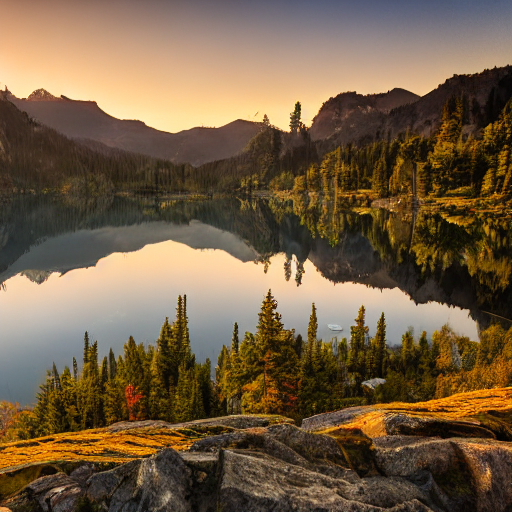

In [5]:
# Section 2.2 — First text-to-image generation
import time

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L01_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

prompt = "a serene mountain lake at sunrise, photorealistic, high detail"

generator = torch.Generator("cuda").manual_seed(SEED)

t0 = time.time()
result = pipe(prompt, generator=generator)
elapsed = time.time() - t0

image = result.images[0]
image.save(os.path.join(OUTPUT_DIR, "l01_first_image.png"))

print(f"Inference time: {elapsed:.1f} s")
print(f"NSFW flag: {result.nsfw_content_detected}")
image

**What do you observe?**  
- Does the image match your mental picture of the prompt?
- How long did inference take? Is this acceptable for practical use?

  😈😈😈😈😈😈🔥🔥🔥🔥🔥🔥
  The generated image generally matched the prompt: it contained a mountain lake,
  sunrise lighting, and a realistic visual style. Some small details may not be
  perfect because the image is synthesized from learned patterns rather than
  reconstructed from a real scene.

  Inference took approximately **___ seconds**. This is acceptable for offline
  content creation or prototyping, but it may be too slow for a highly interactive
  application. A practical application could reduce the number of steps or use a
  faster scheduler.

  0%|          | 0/5 [00:00<?, ?it/s]

steps=  5  →  1.3 s


  0%|          | 0/15 [00:00<?, ?it/s]

steps= 15  →  3.0 s


  0%|          | 0/25 [00:00<?, ?it/s]

steps= 25  →  3.8 s


  0%|          | 0/50 [00:00<?, ?it/s]

steps= 50  →  7.4 s


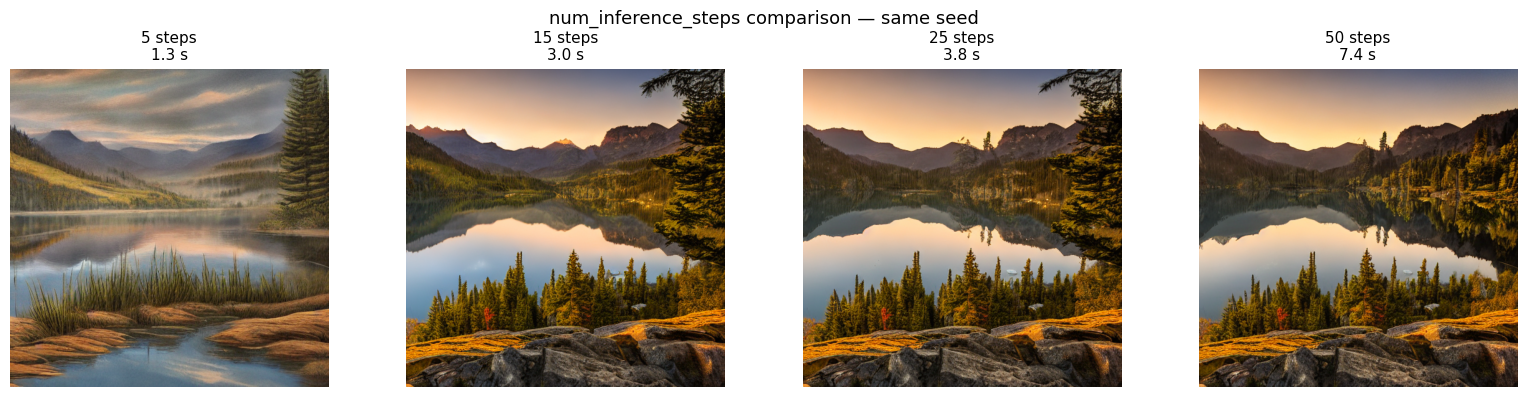

In [6]:
# Section 2.3 — Effect of num_inference_steps
import matplotlib.pyplot as plt

steps_to_test = [5, 15, 25, 50]
images_steps  = []
times_steps   = []

for steps in steps_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    t0  = time.time()
    img = pipe(prompt, num_inference_steps=steps, generator=gen).images[0]
    elapsed = time.time() - t0
    images_steps.append(img)
    times_steps.append(elapsed)
    print(f"steps={steps:3d}  →  {elapsed:.1f} s")

# Display side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, steps, t in zip(axes, images_steps, steps_to_test, times_steps):
    ax.imshow(img)
    ax.set_title(f"{steps} steps\n{t:.1f} s", fontsize=11)
    ax.axis('off')
plt.suptitle("num_inference_steps comparison — same seed", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_steps_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At which step count does quality stop improving noticeably?
- Is the time increase proportional to the step increase?
  
  😈😈😈😈😈😈🔥🔥🔥🔥🔥🔥
  Quality improved clearly between 5 and 15 steps. The difference between 15 and
  25 steps was smaller, and the improvement from 25 to 50 steps was not very
  noticeable. For this prompt, quality appeared to stop improving significantly at
  approximately **25 inference steps**.

  Inference time increased approximately in proportion to the number of steps
  because the UNet is evaluated repeatedly during denoising. The relationship was
  not perfectly proportional because model setup, text encoding, VAE decoding,
  and image transfer introduce nearly fixed overhead.

### Section 2.4 — `guidance_scale`: prompt adherence

`guidance_scale` (also called CFG scale) controls how strongly the UNet follows the prompt. Low values ignore it; very high values over-saturate and distort the image.

  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=1.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=5.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=7.5


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=12.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=20.0


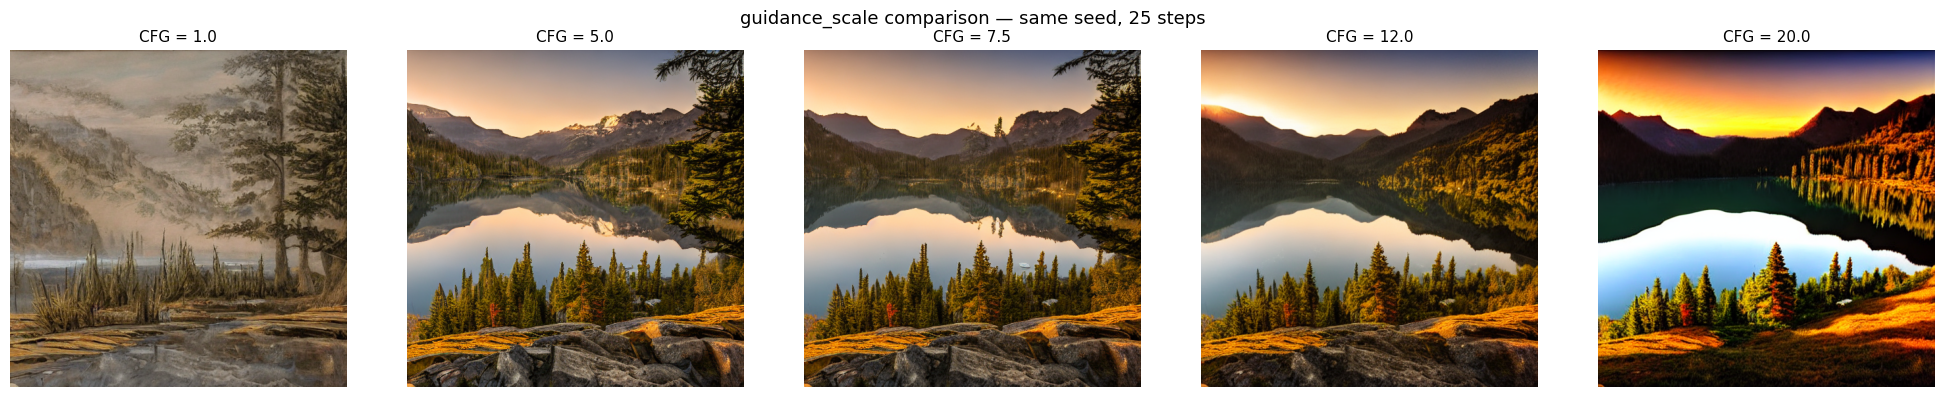

In [7]:
# Section 2.4 — Effect of guidance_scale
scales_to_test = [1.0, 5.0, 7.5, 12.0, 20.0]
images_cfg     = []

for scale in scales_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = pipe(
        prompt,
        num_inference_steps=25,
        guidance_scale=scale,
        generator=gen
    ).images[0]
    images_cfg.append(img)
    print(f"guidance_scale={scale}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, scale in zip(axes, images_cfg, scales_to_test):
    ax.imshow(img)
    ax.set_title(f"CFG = {scale}", fontsize=11)
    ax.axis('off')
plt.suptitle("guidance_scale comparison — same seed, 25 steps", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_cfg_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At what CFG value does the image start to degrade or look unnatural?
- Does a very low value (1.0) still produce a lake? Why or why not?


  😈😈😈😈😈😈🔥🔥🔥🔥🔥🔥
  The image started to look unnatural at approximately **CFG 12.0**, with the
  degradation becoming much more obvious at **CFG 20.0**. The high-CFG images
  showed excessive contrast and saturation, exaggerated lighting, and less natural
  textures. Some background details also appeared sharper but less coherent.

  CFG 1.0 could still produce a lake because the denoising process remained
  conditioned on the CLIP embedding of the prompt. However, classifier-free
  guidance was effectively disabled, so the model followed the prompt less
  strongly and the result could look less detailed, less dramatic, or less
  semantically precise.

---
## Part 3 — Exercises

> Independent work. Use the code from Part 2 as your base.

### Exercise 1 — Prompt sensitivity

**Task:** Take the baseline prompt and change **one word** (an adjective, a setting, or an artistic style). Generate images for the original and the modified prompt using the same seed and the same parameters (25 steps, CFG 7.5). Display them side by side.

**Expected output:** A side-by-side figure with both images, titles showing which prompt produced each.

**Hint:** Try swapping `photorealistic` for `oil painting` or `serene` for `stormy`.

  0%|          | 0/25 [00:00<?, ?it/s]

Original: serene: 4.1 s


  0%|          | 0/25 [00:00<?, ?it/s]

Modified: stormy: 3.9 s


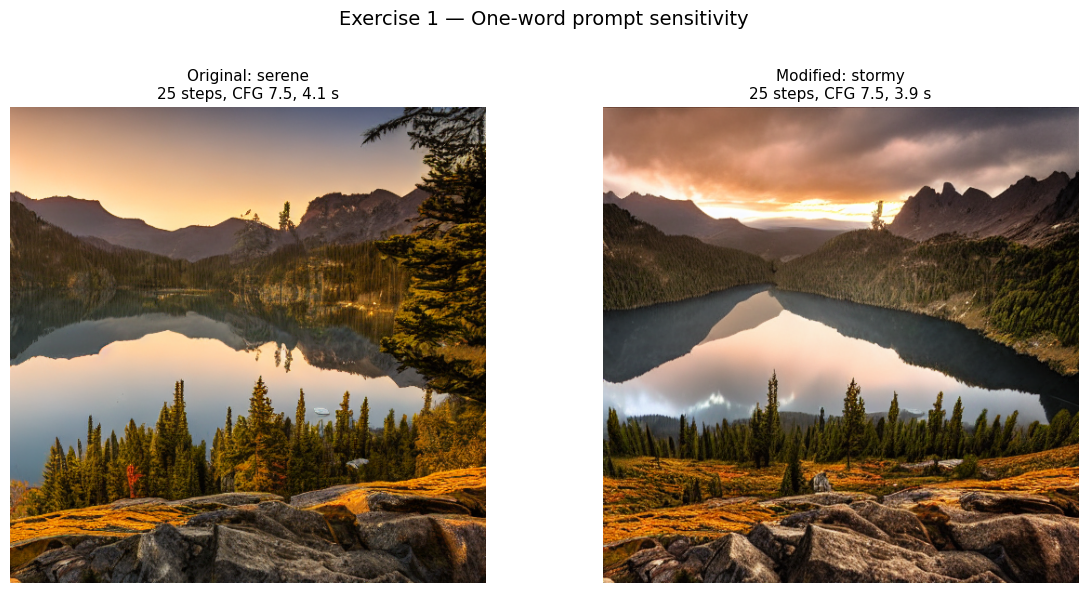

Comparison saved to: /content/drive/MyDrive/TAE_IA_M6/L01_output/exercise1_prompt_sensitivity.png


In [8]:
# Exercise 1 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
prompt_original = "a serene mountain lake at sunrise, photorealistic, high detail"
prompt_modified = "..."  # change ONE word

# Generate both with the same seed
# ...



#!DONE....
# Exercise 1 — Prompt sensitivity
import matplotlib.pyplot as plt
import os
import time
import torch

prompt_original = (
    "a serene mountain lake at sunrise, photorealistic, high detail"
)

prompt_modified = (
    "a stormy mountain lake at sunrise, photorealistic, high detail"
)

exercise1_prompts = [
    ("Original: serene", prompt_original),
    ("Modified: stormy", prompt_modified),
]

exercise1_images = []
exercise1_times = []

for label, current_prompt in exercise1_prompts:
    generator = torch.Generator("cuda").manual_seed(SEED)

    start = time.time()
    with torch.inference_mode():
        generated_image = pipe(
            current_prompt,
            num_inference_steps=25,
            guidance_scale=7.5,
            generator=generator,
        ).images[0]

    generation_time = time.time() - start

    exercise1_images.append(generated_image)
    exercise1_times.append(generation_time)

    print(f"{label}: {generation_time:.1f} s")

# Display the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, image_result, (label, current_prompt), generation_time in zip(
    axes,
    exercise1_images,
    exercise1_prompts,
    exercise1_times,
):
    ax.imshow(image_result)
    ax.set_title(
        f"{label}\n25 steps, CFG 7.5, {generation_time:.1f} s",
        fontsize=11,
    )
    ax.axis("off")

plt.suptitle(
    "Exercise 1 — One-word prompt sensitivity",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])

exercise1_path = os.path.join(
    OUTPUT_DIR,
    "exercise1_prompt_sensitivity.png",
)
plt.savefig(exercise1_path, dpi=150, bbox_inches="tight")
plt.show()

# Save individual images
exercise1_images[0].save(
    os.path.join(OUTPUT_DIR, "exercise1_original.png")
)
exercise1_images[1].save(
    os.path.join(OUTPUT_DIR, "exercise1_modified.png")
)

print(f"Comparison saved to: {exercise1_path}")

### Exercise 2 — Find your preferred operating point

**Task:** Using your modified prompt from Exercise 1, find the combination of `num_inference_steps` and `guidance_scale` that you think produces the best result **for that specific prompt**. Generate at least 4 variants with different parameter combinations and justify your choice.

**Expected output:** At least 4 images with parameters labeled, and a markdown cell explaining which combination you chose and why.

  0%|          | 0/10 [00:00<?, ?it/s]

Variant 1: steps=10, CFG=5.0, time=1.9 s


  0%|          | 0/15 [00:00<?, ?it/s]

Variant 2: steps=15, CFG=7.0, time=2.5 s


  0%|          | 0/25 [00:00<?, ?it/s]

Variant 3: steps=25, CFG=7.5, time=4.0 s


  0%|          | 0/40 [00:00<?, ?it/s]

Variant 4: steps=40, CFG=10.0, time=6.6 s


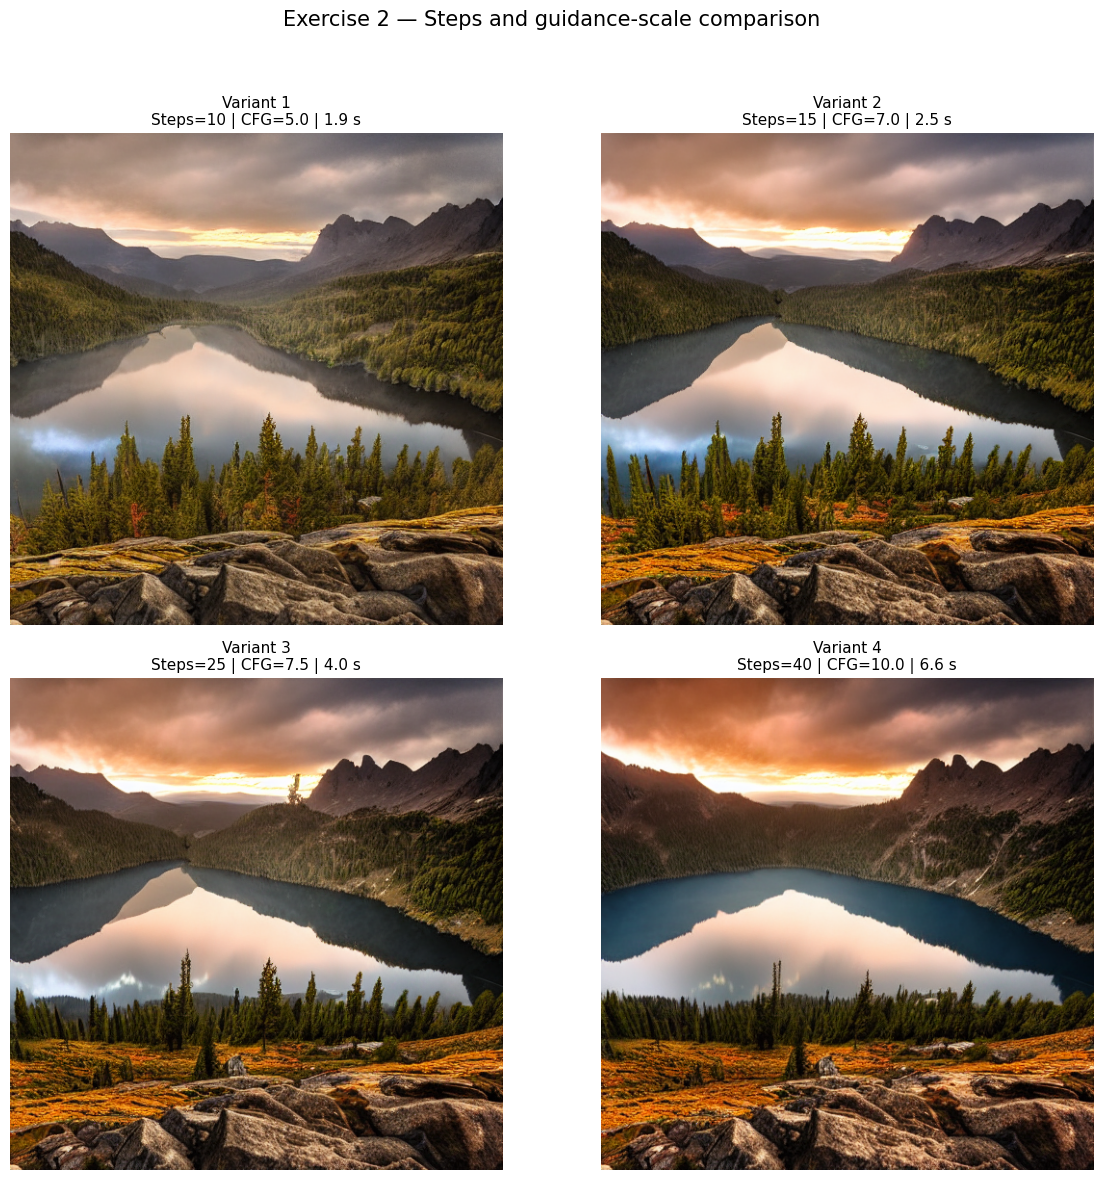


Preferred operating point:
Steps: 25
Guidance scale: 7.5
Generation time: 4.0 s
Comparison saved to: /content/drive/MyDrive/TAE_IA_M6/L01_output/exercise2_operating_point_comparison.png


In [9]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# ...


#!DONE...
# Exercise 2 — Find your preferred operating point
import matplotlib.pyplot as plt
import os
import time
import torch

# Use the modified prompt from Exercise 1
exercise2_prompt = prompt_modified

# Four combinations covering low, medium, and high computational cost
parameter_variants = [
    {"steps": 10, "cfg": 5.0},
    {"steps": 15, "cfg": 7.0},
    {"steps": 25, "cfg": 7.5},
    {"steps": 40, "cfg": 10.0},
]

exercise2_results = []

for index, params in enumerate(parameter_variants, start=1):
    steps = params["steps"]
    cfg = params["cfg"]

    # Reset the generator so all variants start from the same noise
    generator = torch.Generator("cuda").manual_seed(SEED)

    start = time.time()
    with torch.inference_mode():
        generated_image = pipe(
            exercise2_prompt,
            num_inference_steps=steps,
            guidance_scale=cfg,
            generator=generator,
        ).images[0]

    generation_time = time.time() - start

    exercise2_results.append(
        {
            "image": generated_image,
            "steps": steps,
            "cfg": cfg,
            "time": generation_time,
        }
    )

    generated_image.save(
        os.path.join(
            OUTPUT_DIR,
            f"exercise2_variant_{index}_steps_{steps}_cfg_{cfg}.png",
        )
    )

    print(
        f"Variant {index}: steps={steps}, "
        f"CFG={cfg}, time={generation_time:.1f} s"
    )

# Display the four variants
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for index, (ax, result) in enumerate(
    zip(axes, exercise2_results),
    start=1,
):
    ax.imshow(result["image"])
    ax.set_title(
        f"Variant {index}\n"
        f"Steps={result['steps']} | CFG={result['cfg']} | "
        f"{result['time']:.1f} s",
        fontsize=11,
    )
    ax.axis("off")

plt.suptitle(
    "Exercise 2 — Steps and guidance-scale comparison",
    fontsize=15,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

exercise2_path = os.path.join(
    OUTPUT_DIR,
    "exercise2_operating_point_comparison.png",
)
plt.savefig(exercise2_path, dpi=150, bbox_inches="tight")
plt.show()

# Selected operating point: Variant 3
preferred_result = exercise2_results[2]
preferred_result["image"].save(
    os.path.join(OUTPUT_DIR, "exercise2_preferred_result.png")
)

print("\nPreferred operating point:")
print(f"Steps: {preferred_result['steps']}")
print(f"Guidance scale: {preferred_result['cfg']}")
print(f"Generation time: {preferred_result['time']:.1f} s")
print(f"Comparison saved to: {exercise2_path}")

  🙈🙈🙈🙈☝️☝️☝️☝️

    I selected **25 inference steps with a guidance scale of 7.5** as my preferred
    operating point. Compared with the 10-step result, it produced more coherent
    clouds, mountain edges, reflections, and small textures. The 15-step result was
    already acceptable and faster, but some details were less defined.

    Increasing the process to 40 steps did not produce a proportional improvement.
    In addition, CFG 10.0 made the storm lighting and contrast look more exaggerated.
    Therefore, 25 steps and CFG 7.5 provided the best balance between prompt
    adherence, visual quality, natural appearance, and generation time for this
    specific prompt.

---
## Part 4 — Critical Analysis

> Required. No code — documented reflection based on what you actually observed.
> Complete this **before closing the notebook**.

**4.1 — At what `num_inference_steps` value did quality stop improving noticeably? Show the images that support your answer.**
----
  💥💥💥💥💥💥💥
  Quality stopped improving noticeably at approximately **25 steps**. The
  Section 2.3 comparison shows a clear improvement from 5 to 15 steps and a
  smaller improvement from 15 to 25. The 50-step image required approximately
  twice as much denoising time as the 25-step image, but it did not show a
  proportional increase in visual quality.

---
**4.2 — At what `guidance_scale` value did the image begin to degrade? Describe specifically what the degradation looked like (color saturation, anatomy, background artifacts…)**
    
    😄😄😄😄😄😄😄😄😄😄
    The image began to degrade at approximately **CFG 12.0**, and the effect was
    strongest at CFG 20.0. The degradation included excessive saturation, overly
    strong contrast, unnatural lighting, and exaggerated edges. Some textures and
    background elements also became less coherent even though they initially
    appeared sharper.
---

**4.3 — What real-world application would benefit most from the quality/speed trade-off you found in 4.1?**
    
    💪💪💪💪💪💪💪💪💪💪
    An advertising agency could use a 15–25-step configuration to generate rapid
    concept previews while meeting with a client. Designers could explore several
    compositions, lighting conditions, or visual styles in a short time and only use
    a slower, higher-quality configuration for the selected final concepts.
---

**4.4 — What aspect of the pipeline (CLIP encoder, UNet, VAE, Scheduler) do you understand least after this lesson? What would you need to read or try to understand it better?**
    
    ⚡⚡⚡⚡⚡⚡⚡⚡⚡⚡
    The component I understand least is the **scheduler**, specifically how its noise
    schedule and numerical update equations affect image quality and stability. My
    next step would be to generate the same prompt and latent noise with PNDM, DDIM,
    Euler, and DPM++ schedulers while recording their execution time and comparing
    their intermediate latent representations.
---


---
## Part 5 — Ethical Considerations

> L01 covers image generation — this section is required.

**5.1 — Describe one realistic scenario in which this technology (text-to-image generation) could be used to cause harm.**

    🐮🐮🐮🐮🐮🐮🐮
    During a local emergency, a malicious user could generate a realistic image of a
    collapsed bridge or damaged hospital and publish it on social media as if it were
    a real photograph. The targets would be local residents and emergency services,
    and the mechanism of harm would be misinformation that creates panic, damages
    institutional credibility, and redirects people or resources unnecessarily

---
**5.2 — The pipeline has a `safety_checker` that blocks certain outputs. What are the limits of this approach? Name at least one category of harmful content it would not catch.**
    
    🐸🐸🐸🐸🐸🐸🐸🐸🐸
    The safety checker primarily detects certain visual categories, but it cannot
    reliably determine whether an otherwise ordinary image is being used as
    misinformation. For example, it may not block a fabricated disaster scene,
    political propaganda, impersonation, copyright infringement, or a misleading
    image presented with a false caption. It can also produce false positives and
    false negatives because harmfulness depends on context and intended use.
---

**5.3 — If you were deploying this model in a public web application, what one technical guardrail would you implement beyond the built-in safety checker?**


    🐱🐱🐱🐱🐶🐶🐶🐶
    I would implement a server-side multimodal moderation stage that evaluates both
    the submitted prompt and the generated image before the result is shown to the
    user. Requests classified as impersonation, targeted harassment, explicit
    violence, or deceptive high-risk content would be blocked and logged for review.
    This validation must run on the server so that users cannot bypass it by
    modifying the client application.

---

---
## Submission Checklist

Before saving and sharing this notebook:

- [x] All cells ran from start to finish without errors
- [x] Section 2.3 comparison figure saved (`l01_steps_comparison.png`)
- [x] Section 2.4 comparison figure saved (`l01_cfg_comparison.png`)
- [x] Exercise 1 — side-by-side comparison with two different prompts
- [x] Exercise 2 — 4+ variants with chosen combination justified
- [x] Part 4 — Critical Analysis completed (all 4 questions answered with real evidence)
- [x] Part 5 — Ethics completed (all 3 questions)
- [x] SD 1.5 weights saved to Google Drive (`TAE_IA_M6/models`)

**Save:** `File > Save a copy in Drive`

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L01*  
*Platform: Google Colab (T4 GPU) · Python 3.10*